In [8]:
!pip install tensorflow

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import BatchNormalization
from sklearn.model_selection import train_test_split


In [3]:
df= pd.read_csv('C:\\Users\\PMLS\\Documents\\All Uni Work\\Data Science & AI\\skin_disease_data\\hmnist_28_28_RGB.csv')
X= df.drop('label', axis=1).values
y= df['label'].values

df.shape

(10015, 2353)

In [4]:
X = X.reshape(-1, 28, 28, 3) / 255.0


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [33]:

X_train = X_train / 255.0
X_test = X_test / 255.0

datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    # brightness_range=[0.9, 1.1],
    horizontal_flip=True
)
datagen.fit(X_train)


In [39]:
from tensorflow.keras import regularizers

#input shape (28 height , 28 width, 3 channels (RGB))

model = models.Sequential([
    #CNN operations
    #filters = number of feature detectors
    #kernel size = size of the feature detector 3x3
    #padding =  0; to keep the output size same as input size 

    layers.Conv2D(32, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same', kernel_regularizer=regularizers.l2(0.0001), input_shape=(28,28,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),


    layers.Conv2D(128,(3,3),activation=layers.LeakyReLU(alpha=0.01), padding='same', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.Conv2D(128,(3,3),activation=layers.LeakyReLU(alpha=0.01), padding='same', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    layers.Conv2D(256, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),


    #ANN layers --- flattening
    layers.GlobalAveragePooling2D(),
    # layers.Dense(256,activation='relu'),
    # layers.BatchNormalization(),
    # layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.BatchNormalization(),
    layers.Dense(64,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(7, activation='softmax')
])


c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
#learning rate adjustment
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6)

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)



In [41]:
optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003)

model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [42]:
model_prediction = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),epochs=25,validation_data=(X_test, y_test),callbacks=[early_stop, checkpoint, reduce_lr])

Epoch 1/25


c:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


251/251 ━━━━━━━━━━━━━━━━━━━━ 21s 67ms/step - accuracy: 0.1961 - loss: 2.5193 - val_accuracy: 0.6680 - val_loss: 1.7914 - learning_rate: 3.0000e-04
Epoch 2/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.3290 - loss: 1.9778 - val_accuracy: 0.6680 - val_loss: 1.3695 - learning_rate: 3.0000e-04
Epoch 3/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.4760 - loss: 1.6397 - val_accuracy: 0.6680 - val_loss: 1.3431 - learning_rate: 3.0000e-04
Epoch 4/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - accuracy: 0.5756 - loss: 1.4761 - val_accuracy: 0.6680 - val_loss: 2.2027 - learning_rate: 3.0000e-04
Epoch 5/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.6179 - loss: 1.3955 - val_accuracy: 0.6680 - val_loss: 1.9740 - learning_rate: 3.0000e-04
Epoch 6/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - accuracy: 0.6380 - loss: 1.3533 - val_accuracy: 0.6680 - val_loss: 1.2407 - learning_rate: 3.0000e-04
Epoch 7/25
251/251 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accurac

In [43]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

print("Final Training Accuracy:", model_prediction.history['accuracy'][-1])

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6680 - loss: 1.1849
Test Accuracy: 0.6679980158805847
Test Loss: 1.18486487865448
Final Training Accuracy: 0.6694957613945007


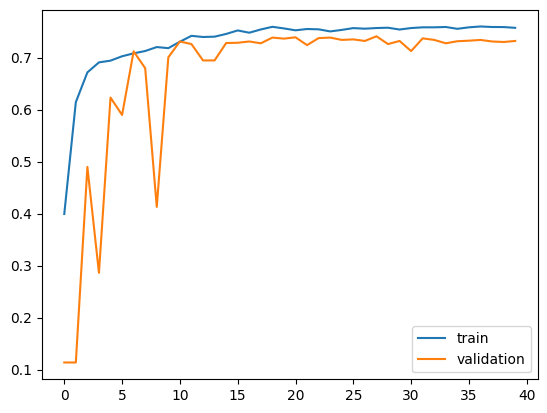

In [11]:
plt.plot(model_prediction.history['accuracy'], label='train')
plt.plot(model_prediction.history['val_accuracy'], label='validation')
plt.legend()
plt.show()